# Credit Scoring Model: Predicting Individual Creditworthiness


**Objective:** Predict whether an individual is a good or bad credit risk using past financial data.

**Approach:** Classification algorithms — Logistic Regression, Decision Tree, and Random Forest — trained on
the **UCI German Credit Data** (Statlog German Credit dataset, 1000 applicants, 20 features).

**Key Features Covered:**
- Feature engineering from financial history (income proxies, debt indicators, payment history, etc.)
- Model accuracy assessment using Precision, Recall, F1-Score, and ROC-AUC
- Comparison across multiple classification algorithms
- Feature importance / interpretability



# Step 1 : Importing all Libraries

In [1]:
# Python Data manipulation Libraries
import pandas as pd
import numpy as np

# Python Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Python Data Preprocessing Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ML Models 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Models Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import warnings
warnings.filterwarnings("ignore")

# Step 2 : Loading Dataset

In [2]:
# Dataset link
# https://www.kaggle.com/datasets/arunjangir245/german-credit-card
df = pd.read_csv("/kaggle/input/datasets/arunjangir245/german-credit-card/GermanCredit.csv")

In [3]:
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [4]:
df.tail()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
995,no checking account,12,existing credits paid back duly till now,radio/television,1736,... < 100 DM,4 <= ... < 7 years,3,female : divorced/separated/married,none,...,real estate,31,none,own,1,unskilled - resident,1,no,yes,1
996,... < 100 DM,30,existing credits paid back duly till now,car (used),3857,... < 100 DM,1 <= ... < 4 years,4,male : divorced/separated,none,...,building society savings agreement/life insurance,40,none,own,1,management/self-employed/highly qualified empl...,1,yes,yes,1
997,no checking account,12,existing credits paid back duly till now,domestic appliances,804,... < 100 DM,... >= 7 years,4,male : single,none,...,car or other,38,none,own,1,skilled employee/official,1,no,yes,1
998,... < 100 DM,45,existing credits paid back duly till now,domestic appliances,1845,... < 100 DM,1 <= ... < 4 years,4,male : single,none,...,unknown/no property,23,none,for free,1,skilled employee/official,1,yes,yes,0
999,0 <= ... < 200 DM,45,critical account/other credits existing,car (used),4576,100 <= ... < 500 DM,unemployed,3,male : single,none,...,car or other,27,none,own,1,skilled employee/official,1,no,yes,1


In [5]:
df.shape

(1000, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [7]:
df.describe()

,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.700000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


# Step 3 : Check Target Column

In [8]:
df.columns.tolist()

['status',
 'duration',
 'credit_history',
 'purpose',
 'amount',
 'savings',
 'employment_duration',
 'installment_rate',
 'personal_status_sex',
 'other_debtors',
 'present_residence',
 'property',
 'age',
 'other_installment_plans',
 'housing',
 'number_credits',
 'job',
 'people_liable',
 'telephone',
 'foreign_worker',
 'credit_risk']

In [9]:
target_column = "credit_risk"
df[target_column].value_counts()
# 1 = Good Score
# 2 = Bad Score

credit_risk
1    700
0    300
Name: count, dtype: int64

# Step 4 : Check Missing Values

In [10]:
df.isnull().sum()

status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

status                     0.0
duration                   0.0
credit_history             0.0
purpose                    0.0
amount                     0.0
savings                    0.0
employment_duration        0.0
installment_rate           0.0
personal_status_sex        0.0
other_debtors              0.0
present_residence          0.0
property                   0.0
age                        0.0
other_installment_plans    0.0
housing                    0.0
number_credits             0.0
job                        0.0
people_liable              0.0
telephone                  0.0
foreign_worker             0.0
credit_risk                0.0
dtype: float64

**If there are missing values**

In [12]:
# For numerical columns:
numeric_columns = df.select_dtypes(include=np.number).columns
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [13]:
#For categorical columns:
categorical_columns = df.select_dtypes(include="object").columns
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
df.isnull().sum().sum()

np.int64(0)

# Step 5 : Check Duplicate Rows

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
# If duplicates exist:
df = df.drop_duplicates()
df.shape

(1000, 21)

# Step 6 : Exploratory Data Analysis (EDA)

**Target Distribution**

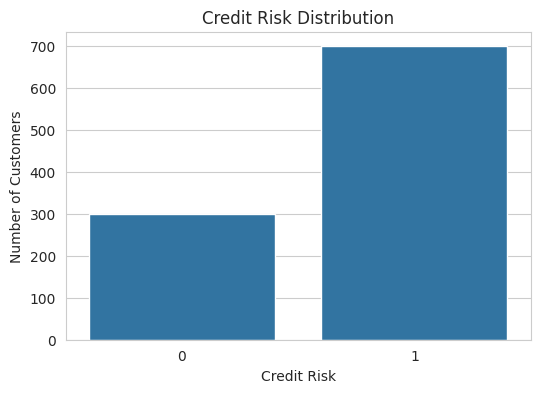

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x=df[target_column])
plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Customers")
plt.show()

**Numerical Features**

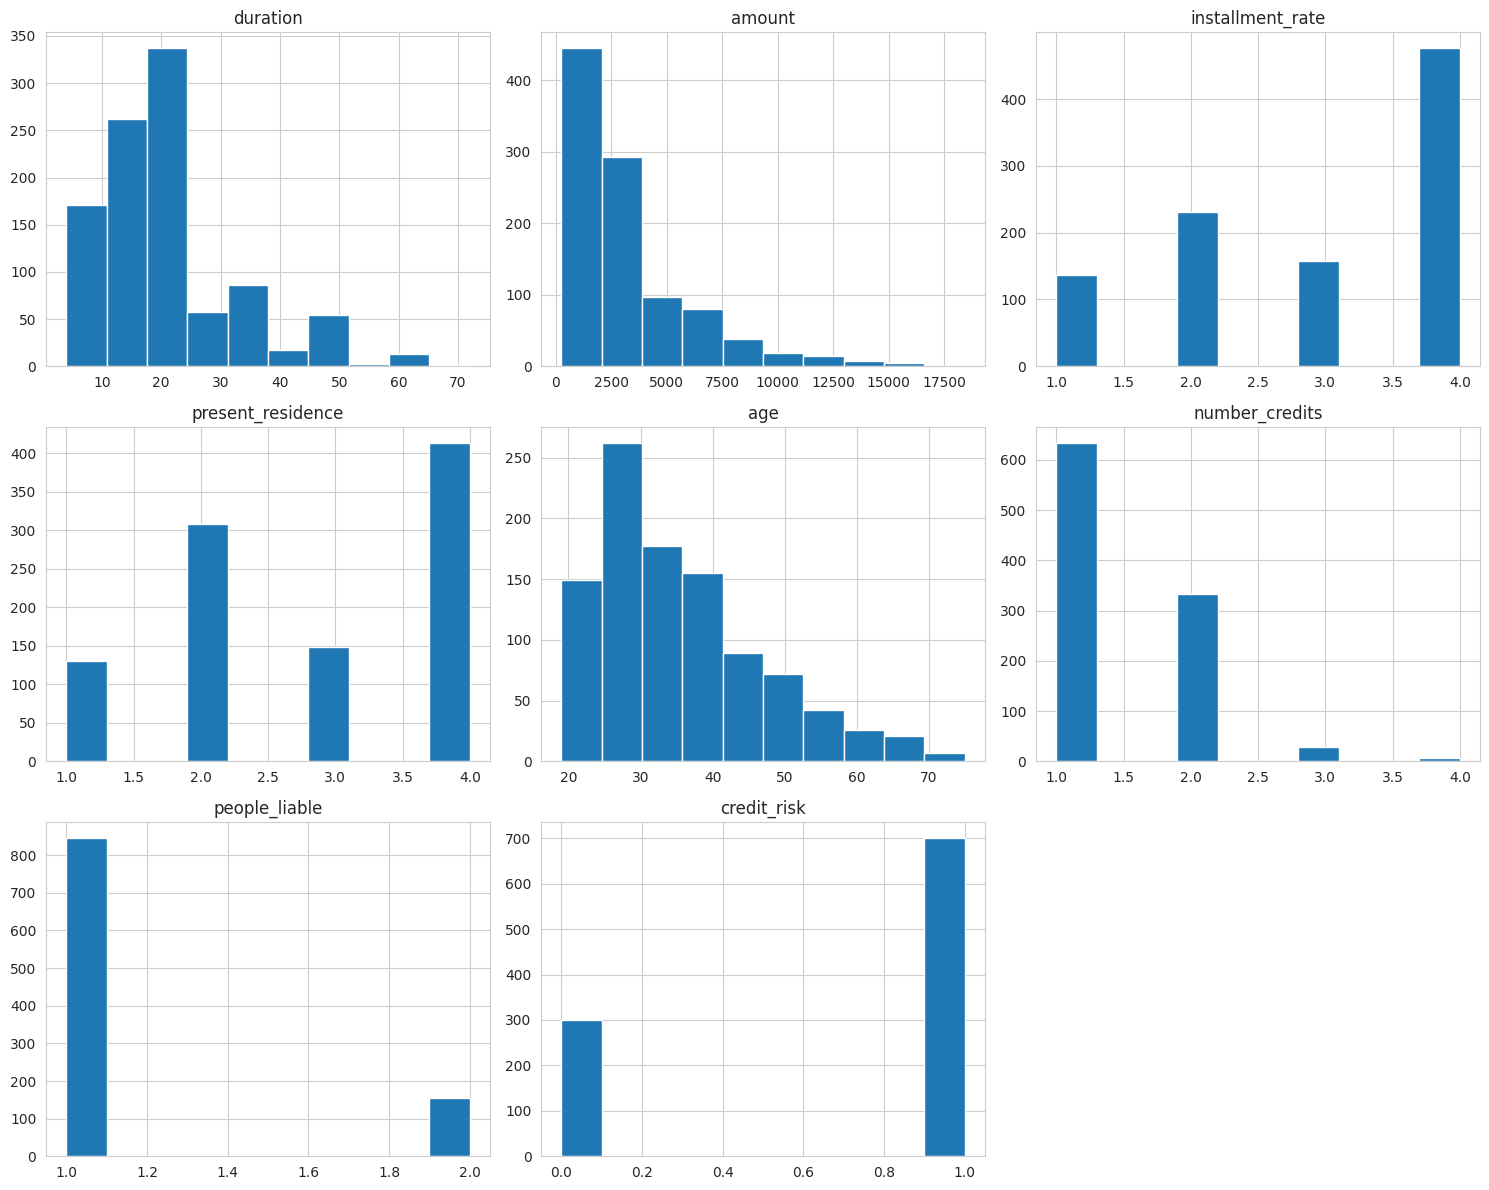

In [18]:
df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

**Correlation Matrix**

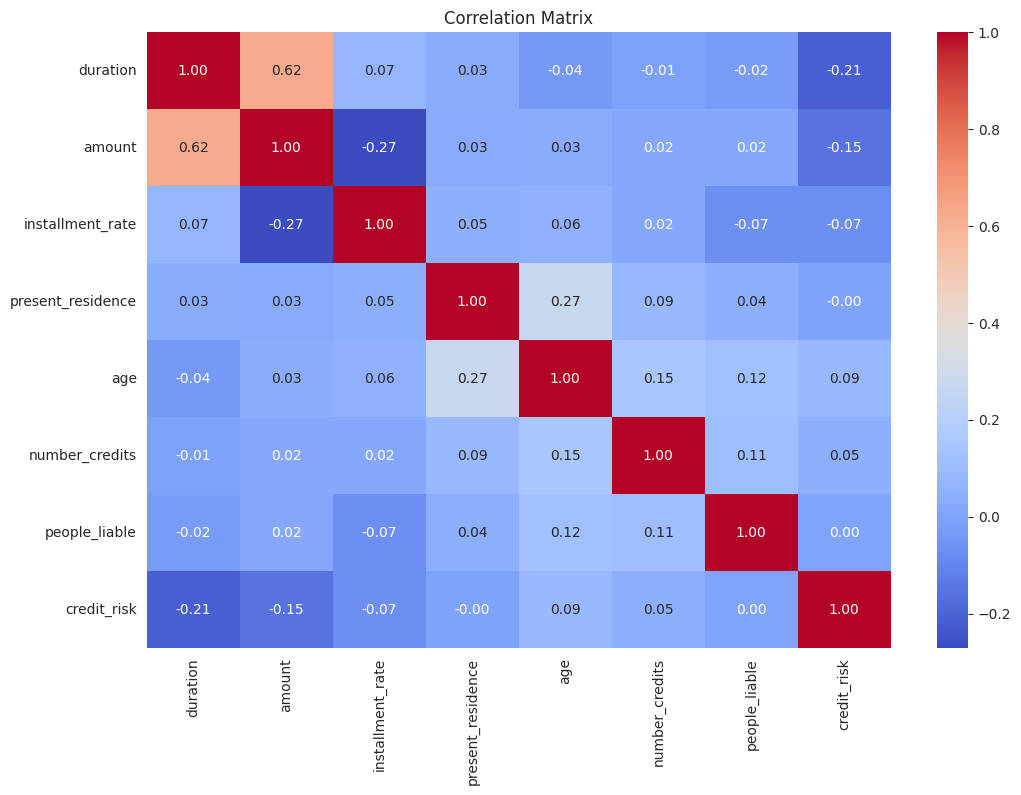

In [19]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# Step 7 — Feature Engineering

**Feature 1 : Loan amount per month**

In [20]:
df["amount_per_month"] = df["amount"] / df["duration"]
df.head(5)

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk,amount_per_month
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,67,none,own,2,skilled employee/official,1,yes,yes,1,194.833333
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,22,none,own,1,skilled employee/official,1,no,yes,0,123.979167
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,49,none,own,1,unskilled - resident,2,no,yes,1,174.666667
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,45,none,for free,1,skilled employee/official,2,no,yes,1,187.666667
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,53,none,for free,2,skilled employee/official,2,no,yes,0,202.916667


**Feature 2 : Loan duration category**

In [21]:
df["duration_category"] = pd.cut(
    df["duration"],
    bins=[0, 12, 24, 48, np.inf],
    labels=["Short", "Medium", "Long", "Very_Long"]
)

In [22]:
df[["duration", "duration_category"]].head()

,duration,duration_category
0,6,Short
1,48,Long
2,12,Short
3,42,Long
4,24,Medium


**Feature 3 : Age group**

In [23]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 50, 100],
    labels=["Young", "Adult", "Middle_Age", "Senior"]
)

In [24]:
df[["age", "age_group"]].head()

,age,age_group
0,67,Senior
1,22,Young
2,49,Middle_Age
3,45,Middle_Age
4,53,Senior


# Step 8 : Correlation Analysis

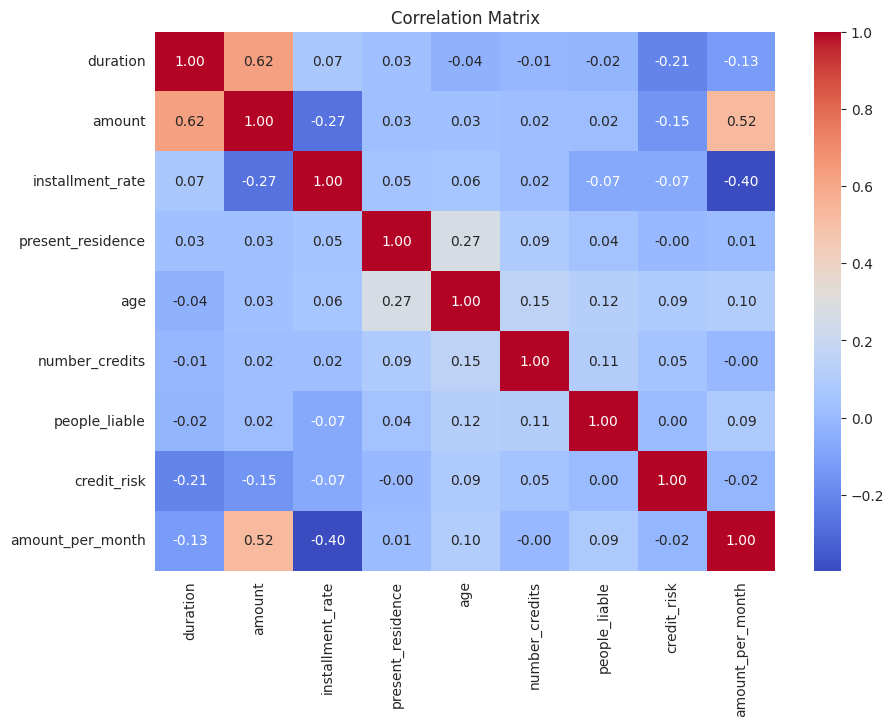

In [25]:
plt.figure(figsize=(10,7))

correlation = df.select_dtypes(
    include=np.number
).corr()
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Matrix")

plt.show()

# Step 9 : Analyze Credit Amount

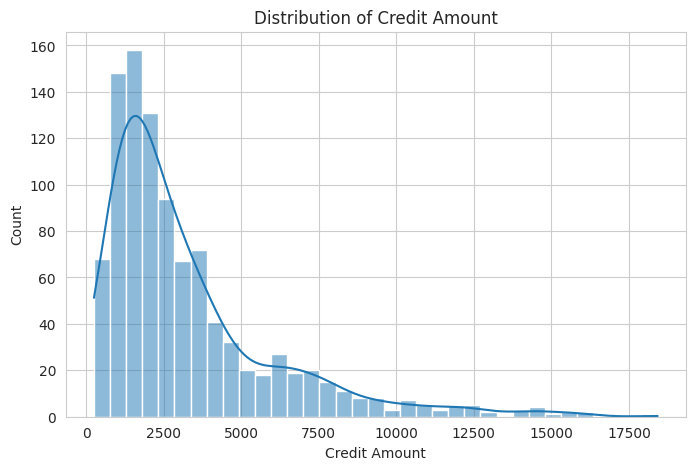

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="amount",
    kde=True
)

plt.title("Distribution of Credit Amount")
plt.xlabel("Credit Amount")
plt.show()

# Step 10 : Credit Amount vs Credit Risk

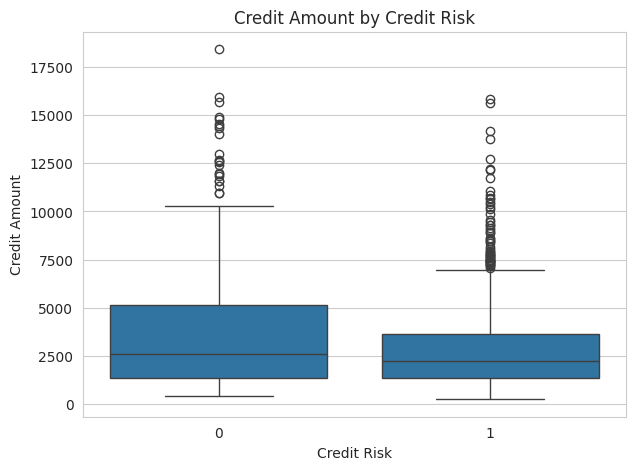

In [27]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="credit_risk",
    y="amount"
)
plt.title("Credit Amount by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Credit Amount")
plt.show()

# Step 11 : Age vs Credit Risk

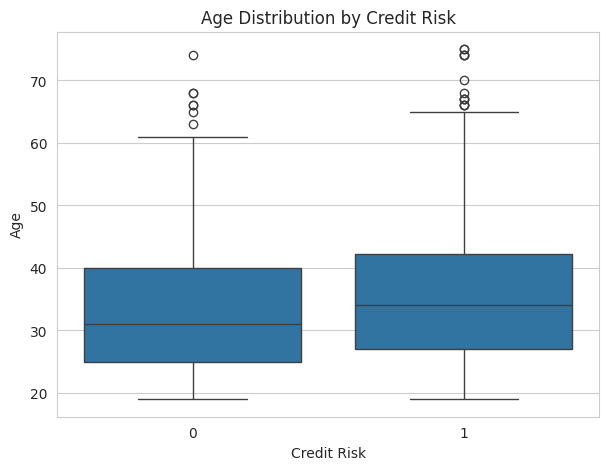

In [28]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="credit_risk",
    y="age"
)
plt.title("Age Distribution by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Age")
plt.show()

# Step 12 : Loan Duration vs Credit Risk

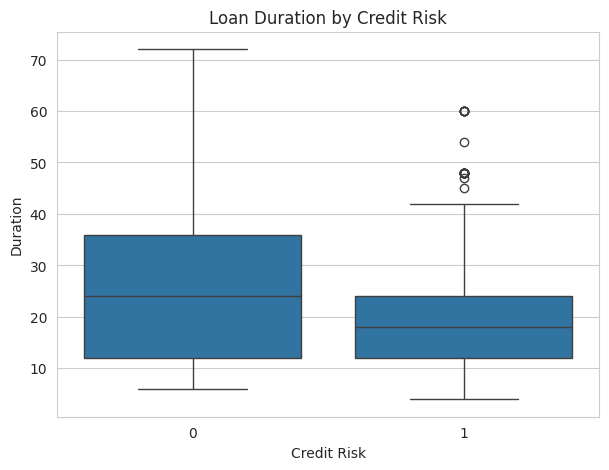

In [29]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="credit_risk",
    y="duration"
)
plt.title("Loan Duration by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Duration")
plt.show()

In [30]:
# Separate features and target

X = df.drop(columns=["credit_risk"])
y = df["credit_risk"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 23)
y shape: (1000,)


In [31]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['duration', 'amount', 'installment_rate', 'present_residence', 'age', 'number_credits', 'people_liable', 'amount_per_month']

Categorical Features:
['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker', 'duration_category', 'age_group']


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (800, 23)
Testing data: (200, 23)

Training target distribution:
credit_risk
1    560
0    240
Name: count, dtype: int64

Testing target distribution:
credit_risk
1    140
0     60
Name: count, dtype: int64


In [33]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [34]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [35]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [37]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (800, 23)
Processed training shape: (800, 70)
Original testing shape: (200, 23)
Processed testing shape: (200, 70)


**Create the models**

In [38]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

In [39]:
from sklearn.pipeline import Pipeline

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.
Extra Trees trained successfully.
Naive Bayes trained successfully.
KNN trained successfully.


In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [41]:
results = []

for name, model in trained_models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability of class 1
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

In [42]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.770,0.790123,0.914286,0.847682,0.796667
4,Extra Trees,0.740,0.785714,0.864286,0.823129,0.795952
3,Gradient Boosting,0.750,0.800000,0.857143,0.827586,0.777262
0,Logistic Regression,0.705,0.779310,0.807143,0.792982,0.764286
5,Naive Bayes,0.685,0.823529,0.700000,0.756757,0.718036
6,KNN,0.715,0.751515,0.885714,0.813115,0.687321
1,Decision Tree,0.625,0.755906,0.685714,0.719101,0.584524


In [43]:
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.770,0.7901,0.9143,0.8477,0.7967
4,Extra Trees,0.740,0.7857,0.8643,0.8231,0.7960
3,Gradient Boosting,0.750,0.8000,0.8571,0.8276,0.7773
0,Logistic Regression,0.705,0.7793,0.8071,0.7930,0.7643
5,Naive Bayes,0.685,0.8235,0.7000,0.7568,0.7180
6,KNN,0.715,0.7515,0.8857,0.8131,0.6873
1,Decision Tree,0.625,0.7559,0.6857,0.7191,0.5845


In [44]:
results_percentage = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

results_percentage[metric_columns] = (
    results_percentage[metric_columns] * 100
).round(2)

results_percentage

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,77.0,79.01,91.43,84.77,79.67
4,Extra Trees,74.0,78.57,86.43,82.31,79.60
3,Gradient Boosting,75.0,80.00,85.71,82.76,77.73
0,Logistic Regression,70.5,77.93,80.71,79.30,76.43
5,Naive Bayes,68.5,82.35,70.00,75.68,71.80
6,KNN,71.5,75.15,88.57,81.31,68.73
1,Decision Tree,62.5,75.59,68.57,71.91,58.45


In [45]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [46]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [47]:
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.770,0.7901,0.9143,0.8477,0.7967
4,Extra Trees,0.740,0.7857,0.8643,0.8231,0.7960
3,Gradient Boosting,0.750,0.8000,0.8571,0.8276,0.7773
0,Logistic Regression,0.705,0.7793,0.8071,0.7930,0.7643
5,Naive Bayes,0.685,0.8235,0.7000,0.7568,0.7180
6,KNN,0.715,0.7515,0.8857,0.8131,0.6873
1,Decision Tree,0.625,0.7559,0.6857,0.7191,0.5845


In [48]:
print("Best Model:", best_model_name)

Best Model: Random Forest


<Figure size 1200x600 with 0 Axes>

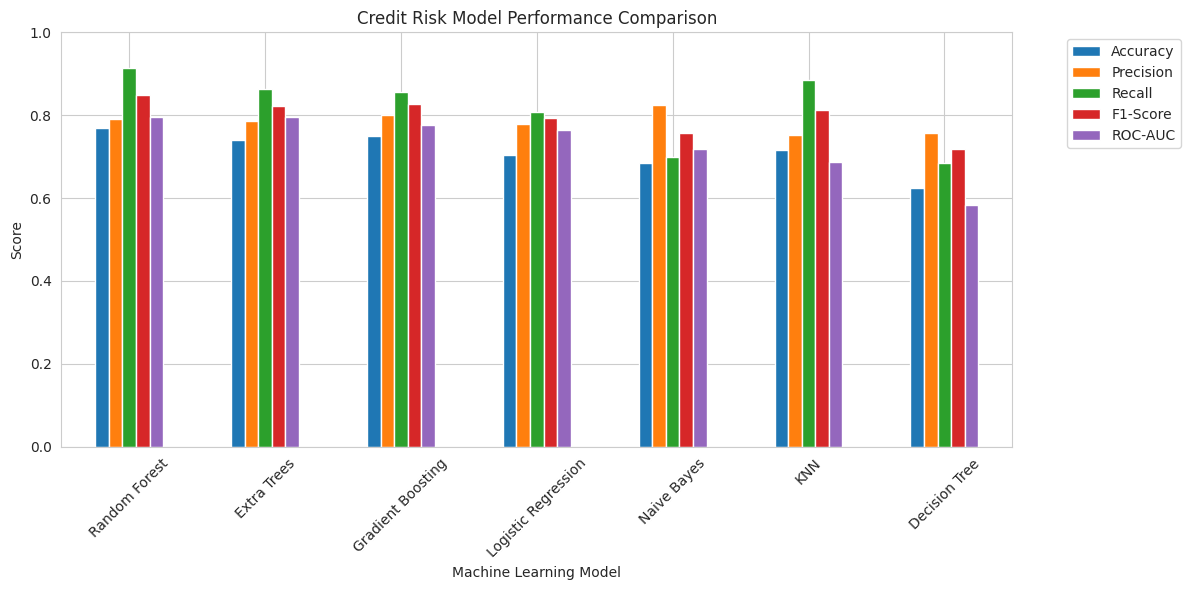

In [49]:
plt.figure(figsize=(12, 6))

results_plot = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Credit Risk Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Machine Learning Model")
plt.ylim(0, 1)

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [50]:
best_model = trained_models["Random Forest"]

y_pred_best = best_model.predict(X_test)

y_prob_best = best_model.predict_proba(X_test)[:, 1]

In [51]:
print("Random Forest Performance")
print("-------------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_best)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_best)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_best)
)

print(
    "F1-Score:",
    f1_score(y_test, y_pred_best)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_best)
)

Random Forest Performance
-------------------------
Accuracy: 0.77
Precision: 0.7901234567901234
Recall: 0.9142857142857143
F1-Score: 0.847682119205298
ROC-AUC: 0.7966666666666666


In [52]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=[
            "Bad Credit",
            "Good Credit"
        ]
    )
)

              precision    recall  f1-score   support

  Bad Credit       0.68      0.43      0.53        60
 Good Credit       0.79      0.91      0.85       140

    accuracy                           0.77       200
   macro avg       0.74      0.67      0.69       200
weighted avg       0.76      0.77      0.75       200



In [53]:
from sklearn.metrics import confusion_matrix

confusion_matrix = confusion_matrix(
    y_test,
    y_pred_best
)

print(confusion_matrix)

[[ 26  34]
 [ 12 128]]


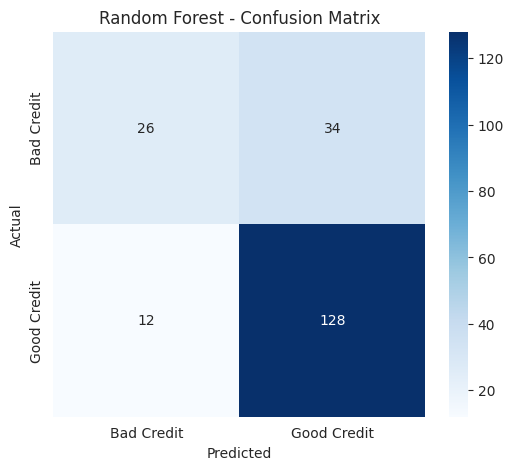

In [54]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bad Credit", "Good Credit"],
    yticklabels=["Bad Credit", "Good Credit"]
)

plt.title("Random Forest - Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [55]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_best
)

auc_score = roc_auc_score(
    y_test,
    y_prob_best
)

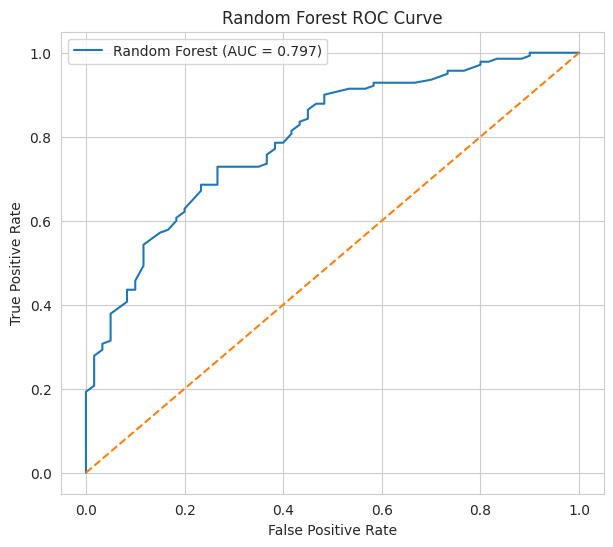

In [56]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

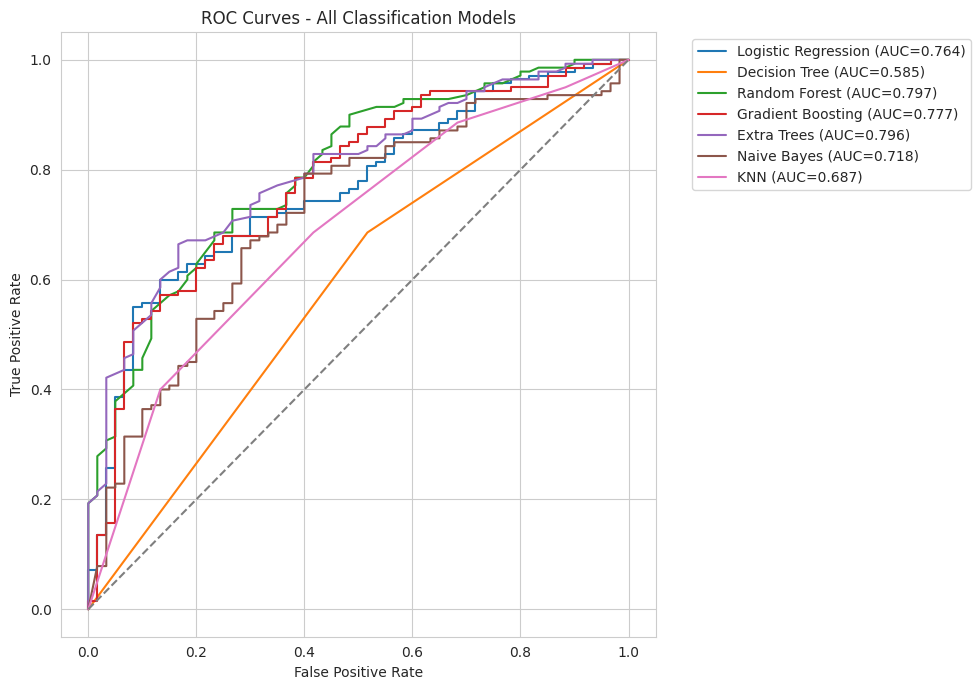

In [57]:
plt.figure(figsize=(10, 7))

for name, model in trained_models.items():

    y_probability = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_probability
    )
    auc = roc_auc_score(
        y_test,
        y_probability
    )
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves - All Classification Models")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [58]:
rf_model = best_model.named_steps["model"]

In [59]:
fitted_preprocessor = best_model.named_steps["preprocessor"]

In [60]:
feature_names = fitted_preprocessor.get_feature_names_out()

In [61]:
feature_importance = rf_model.feature_importances_

In [62]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

In [63]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)
importance_df.head(20)

,Feature,Importance
7,num__amount_per_month,0.086992
1,num__amount,0.085334
0,num__duration,0.063042
4,num__age,0.059723
11,cat__status_no checking account,0.045041
8,cat__status_... < 100 DM,0.033644
3,num__present_residence,0.027629
2,num__installment_rate,0.026263
27,cat__savings_... < 100 DM,0.020452
13,cat__credit_history_critical account/other cre...,0.019034


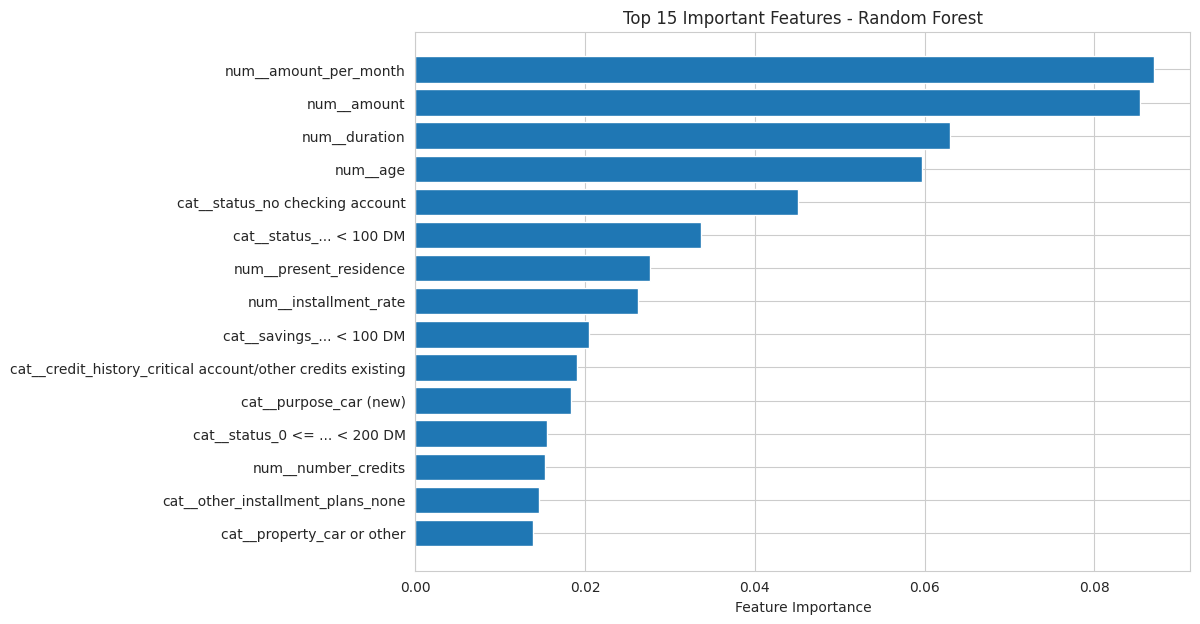

In [64]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 15 Important Features - Random Forest"
)

plt.xlabel("Feature Importance")

plt.show()

In [65]:
!pip install shap

In [66]:
import shap

In [67]:
X_test_transformed = fitted_preprocessor.transform(X_test)

In [68]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(
    X_test_transformed
)

In [69]:
shap_values

array([[[-0.00273593,  0.00273593],
        [-0.02495587,  0.02495587],
        [ 0.01046244, -0.01046244],
        ...,
        [-0.01238325,  0.01238325],
        [-0.00067136,  0.00067136],
        [-0.00386533,  0.00386533]],

       [[ 0.04684576, -0.04684576],
        [-0.00474398,  0.00474398],
        [ 0.01001968, -0.01001968],
        ...,
        [ 0.00526132, -0.00526132],
        [ 0.00183154, -0.00183154],
        [-0.004882  ,  0.004882  ]],

       [[ 0.0478343 , -0.0478343 ],
        [ 0.09513986, -0.09513986],
        [-0.01722949,  0.01722949],
        ...,
        [-0.01513299,  0.01513299],
        [-0.00099195,  0.00099195],
        [-0.00663234,  0.00663234]],

       ...,

       [[-0.00182612,  0.00182612],
        [ 0.02916087, -0.02916087],
        [-0.02308029,  0.02308029],
        ...,
        [ 0.00460846, -0.00460846],
        [ 0.00206012, -0.00206012],
        [-0.00390726,  0.00390726]],

       [[-0.04479601,  0.04479601],
        [-0.00894208,  0.00